In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [2]:
def plot_predictions(test, predicted, title='IBM Stock Price Prediction'):
    plt.figure(figsize=(14, 5))
    plt.plot(test,      color='red',  label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae  = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}.".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [3]:
# Blok 3 – Wczytanie danych
# Można użyć też innych danych z cenami akcji: Google (GOOGL), Amazon (AMZN)
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv',
                      index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [4]:
training_set = dataset[:'2016'].iloc[:, 1:2].values
test_set     = dataset['2017':].iloc[:, 1:2].values

print(f"Rozmiar zbioru treningowego: {training_set.shape}")
print(f"Rozmiar zbioru testowego:    {test_set.shape}")

Rozmiar zbioru treningowego: (2769, 1)
Rozmiar zbioru testowego:    (251, 1)


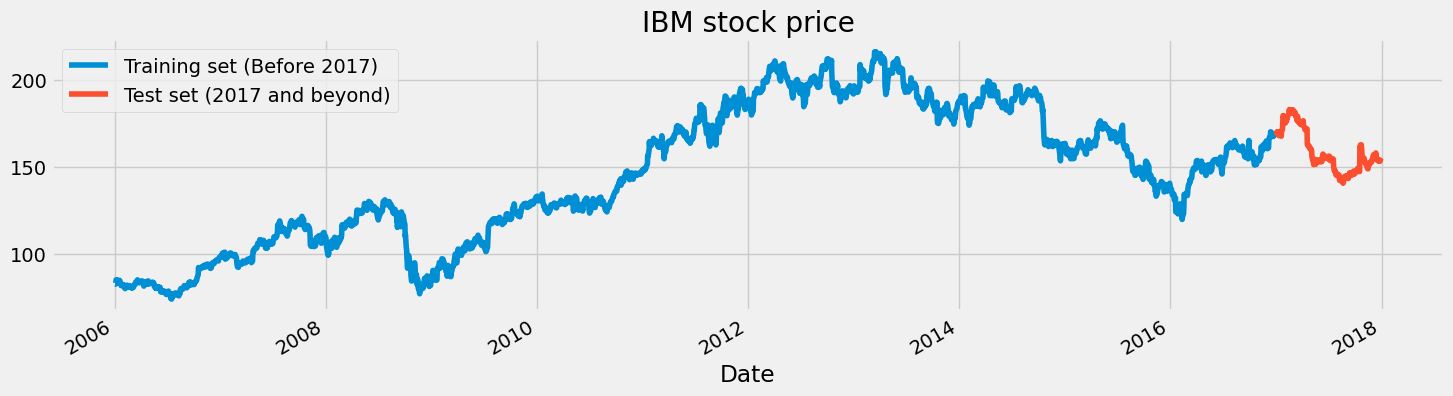

In [5]:
dataset["High"][:'2016'].plot(figsize=(16, 4), legend=True)
dataset["High"]['2017':].plot(figsize=(16, 4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [6]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [7]:
X_train = []
y_train = []

n_train = len(training_set_scaled)
for i in range(60, n_train):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
print(f"X_train shape: {X_train.shape}")

X_train shape: (2709, 60)


In [8]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

## Ćw 1

In [9]:
regressor = Sequential()

regressor.add(Input(shape=(X_train.shape[1], 1)))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

regressor.fit(X_train, y_train, epochs=50, batch_size=32)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0205
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0095
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0083
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0074
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0062
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0049
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0038
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0035
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0032
Epoc

In [10]:
dataset_total = pd.concat(
    (dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0
)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [11]:
X_test = []
n_test = len(test_set)
for i in range(60, 60 + n_test):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


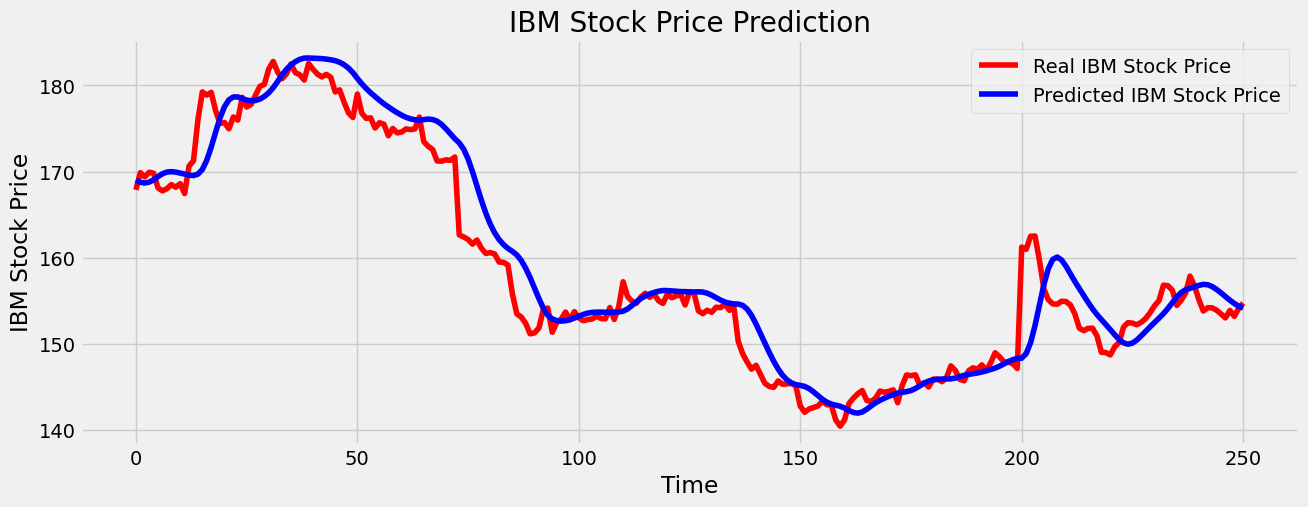

In [12]:
plot_predictions(test_set, predicted_stock_price)

In [13]:
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.25.
------------------------------
Średni błąd bezwzględny: 2.28.
Średni błąd bezwzględny procentowy: 1.43%
------------------------------


---
## Ćw 2

In [14]:
regressorGRU = Sequential()

regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Warstwa wyjściowa
regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0195
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0080
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0069
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0061
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0053
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0048
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0045
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0038
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0035
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

In [15]:
X_test = []
for i in range(60, 60 + n_test):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


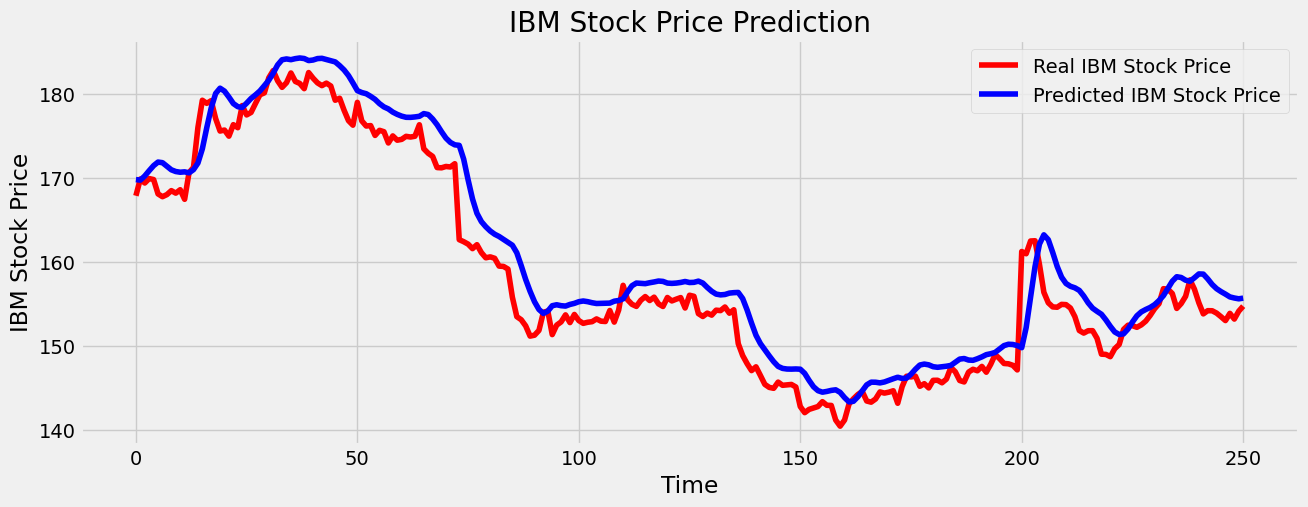

In [16]:
plot_predictions(test_set, GRU_predicted_stock_price)

In [17]:
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.32.
------------------------------
Średni błąd bezwzględny: 2.75.
Średni błąd bezwzględny procentowy: 1.74%
------------------------------


---
## eksperymenty A–G


In [18]:
def build_and_train_lstm(units=50, optimizer='rmsprop', loss='mean_squared_error',
                          epochs=50, batch_size=32, early_stopping=False,
                          patience=5, validation_split=0.0):
    model = Sequential([
        Input(shape=(X_train.shape[1], 1)),
        LSTM(units, return_sequences=True), Dropout(0.2),
        LSTM(units, return_sequences=True), Dropout(0.2),
        LSTM(units, return_sequences=True), Dropout(0.2),
        LSTM(units),                        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss=loss)
    callbacks = []
    if early_stopping:
        monitor = 'val_loss' if validation_split > 0 else 'loss'
        callbacks.append(EarlyStopping(monitor=monitor, patience=patience,
                                       restore_best_weights=True))
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
              validation_split=validation_split, callbacks=callbacks)
    return model


def predict_and_evaluate(model, label='Model'):
    X_t = []
    for i in range(60, 60 + n_test):
        X_t.append(inputs[i-60:i, 0])
    X_t = np.reshape(np.array(X_t), (-1, 60, 1))
    pred = sc.inverse_transform(model.predict(X_t))
    plot_predictions(test_set, pred, title=f'IBM Stock Price – {label}')
    return_rmse(test_set, pred)
    return_mae(test_set, pred)
    return pred


LSTM units = 32
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0218
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0100
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0084
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0071
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0062
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0058
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0056
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0054
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0048
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0047
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0042
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0038
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0039
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - 

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


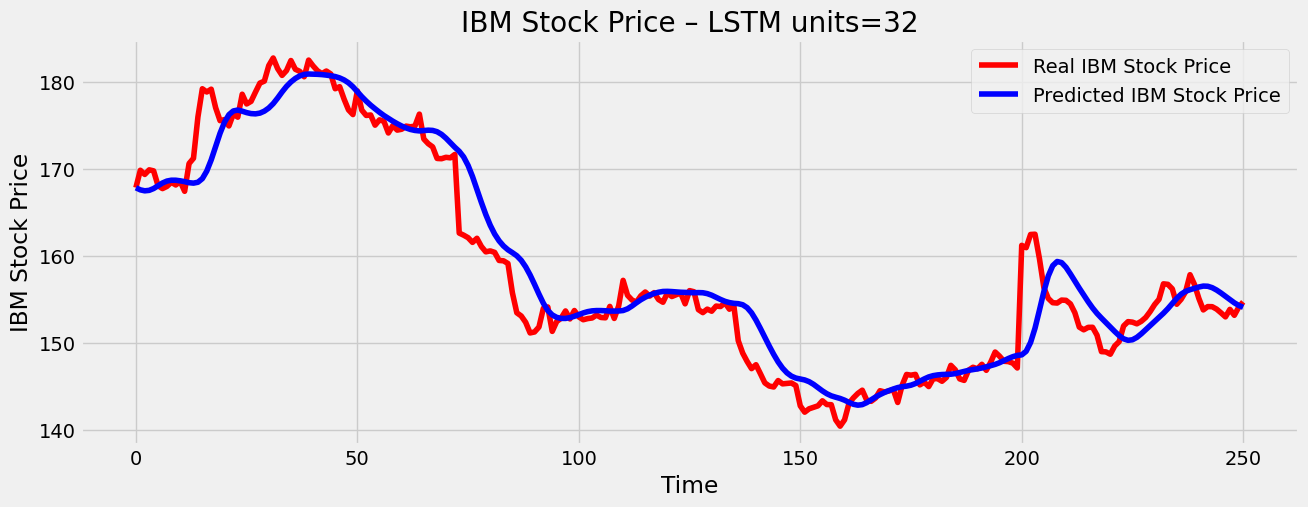

------------------------------
Błąd średniokwadratowy modelu 3.16.
------------------------------
Średni błąd bezwzględny: 2.12.
Średni błąd bezwzględny procentowy: 1.34%
------------------------------

LSTM units = 50
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0263
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0114
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0082
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0077
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0063
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0051
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0048
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0046
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0041
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0040
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step -

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


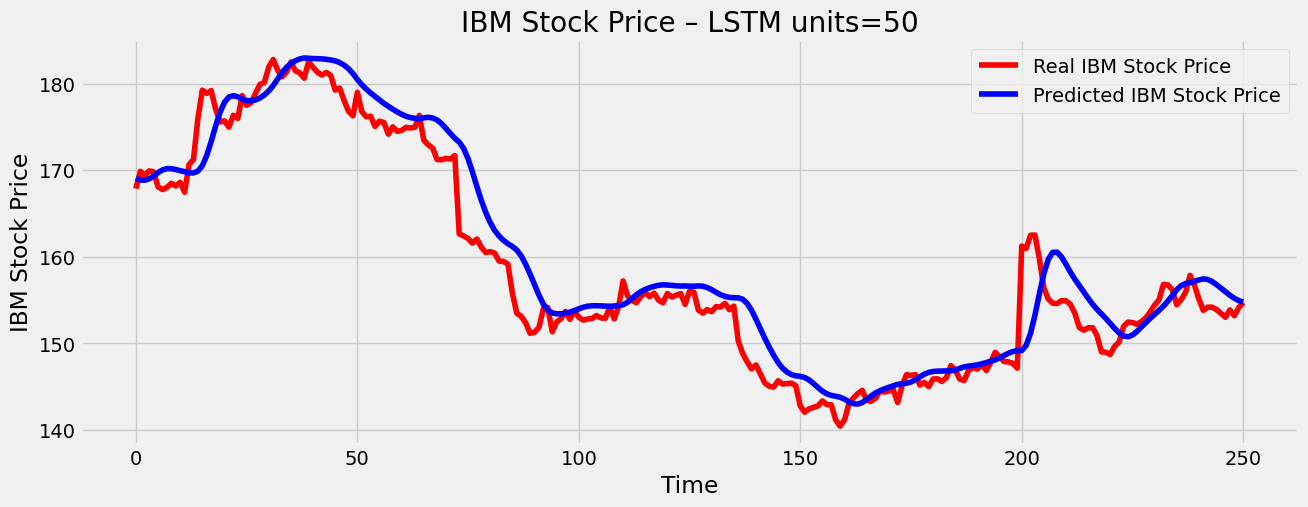

------------------------------
Błąd średniokwadratowy modelu 3.28.
------------------------------
Średni błąd bezwzględny: 2.41.
Średni błąd bezwzględny procentowy: 1.52%
------------------------------

LSTM units = 100
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0388
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0124
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0089
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0070
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0060
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0050
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0043
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0040
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0035
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step 

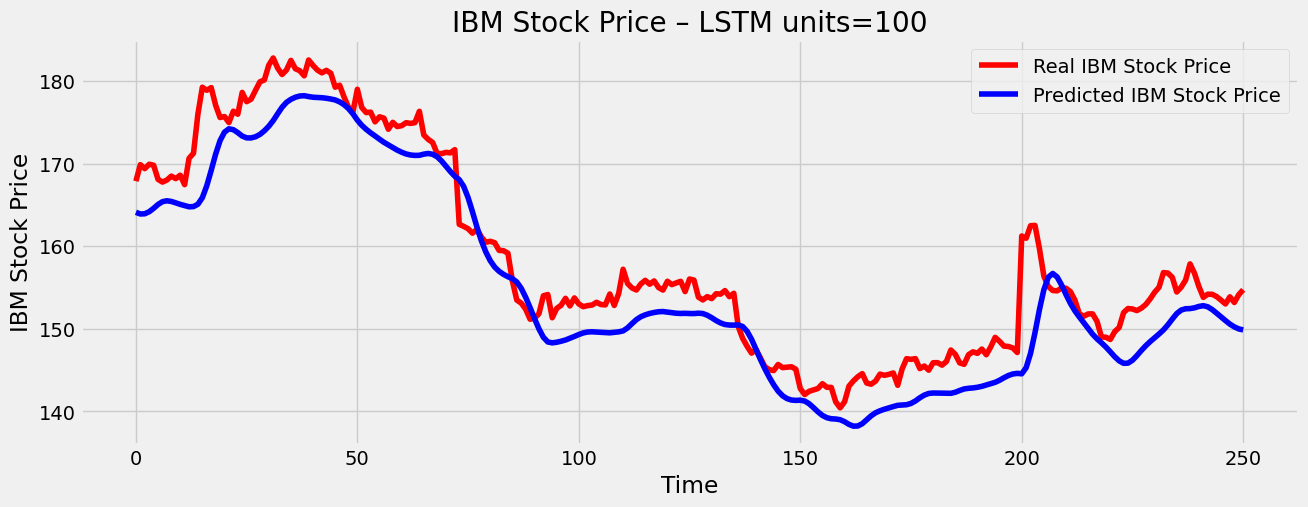

------------------------------
Błąd średniokwadratowy modelu 4.37.
------------------------------
Średni błąd bezwzględny: 3.64.
Średni błąd bezwzględny procentowy: 2.30%
------------------------------


In [19]:
for units in [32, 50, 100]:
    print(f"\n{'='*50}\nLSTM units = {units}\n{'='*50}")
    m = build_and_train_lstm(units=units, epochs=50)
    predict_and_evaluate(m, label=f'LSTM units={units}')


Optimizer: rmsprop
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0209
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0102
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0076
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0077
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0059
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0050
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0050
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0043
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0039
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0038
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

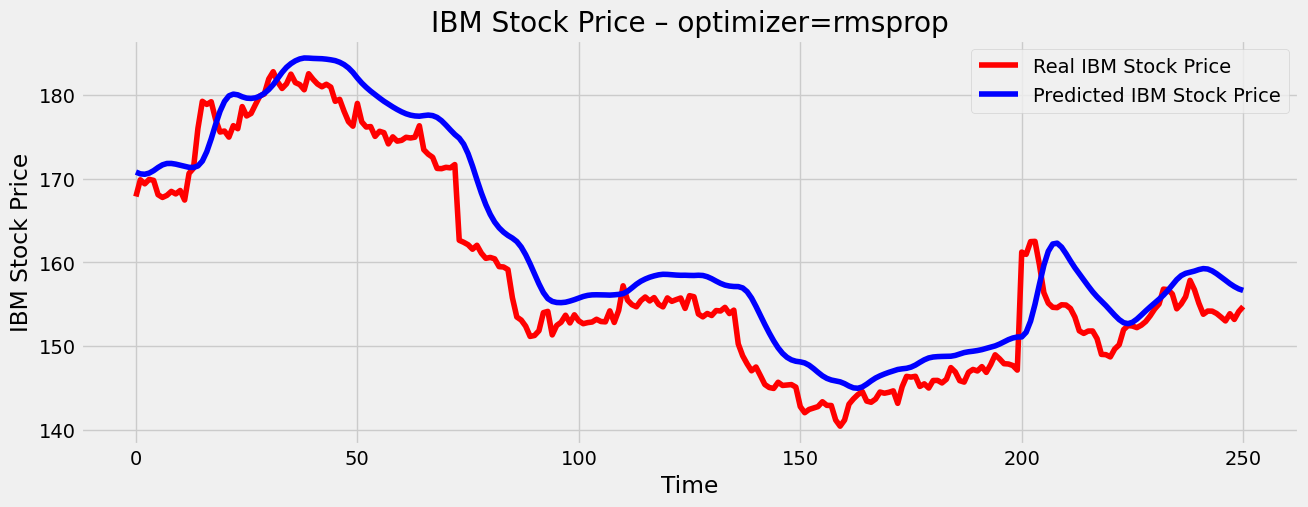

------------------------------
Błąd średniokwadratowy modelu 4.37.
------------------------------
Średni błąd bezwzględny: 3.74.
Średni błąd bezwzględny procentowy: 2.38%
------------------------------

Optimizer: adam
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0253
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0053
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0044
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0049
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0036
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0038
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0034
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0031
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0032
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step -

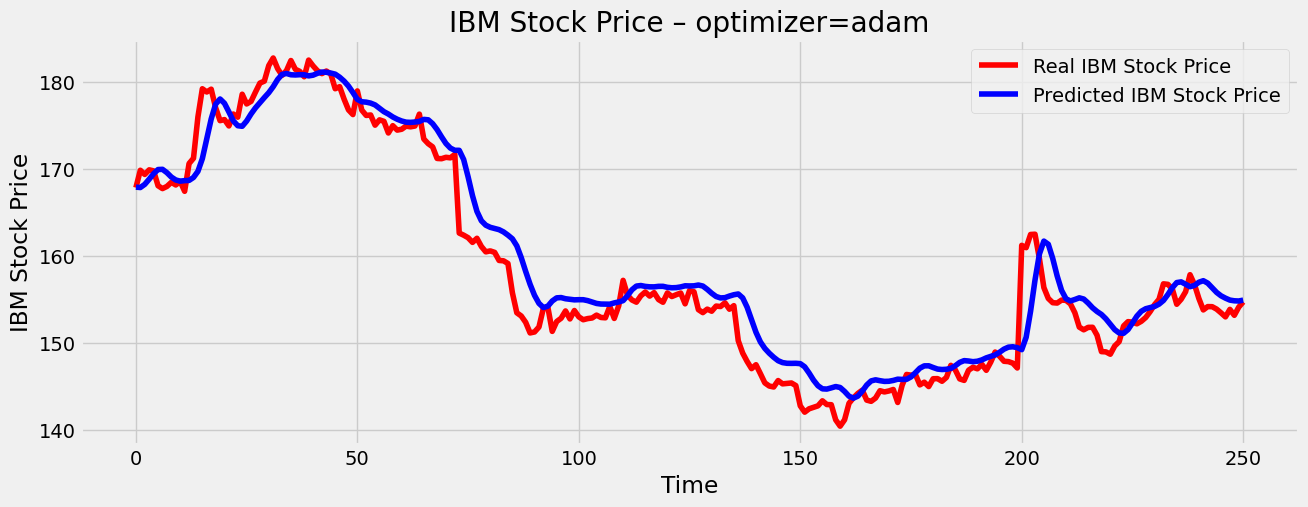

------------------------------
Błąd średniokwadratowy modelu 2.88.
------------------------------
Średni błąd bezwzględny: 2.14.
Średni błąd bezwzględny procentowy: 1.37%
------------------------------

Optimizer: SGD
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0553
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0042
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0038
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0037
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0030
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0029
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0029
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - 

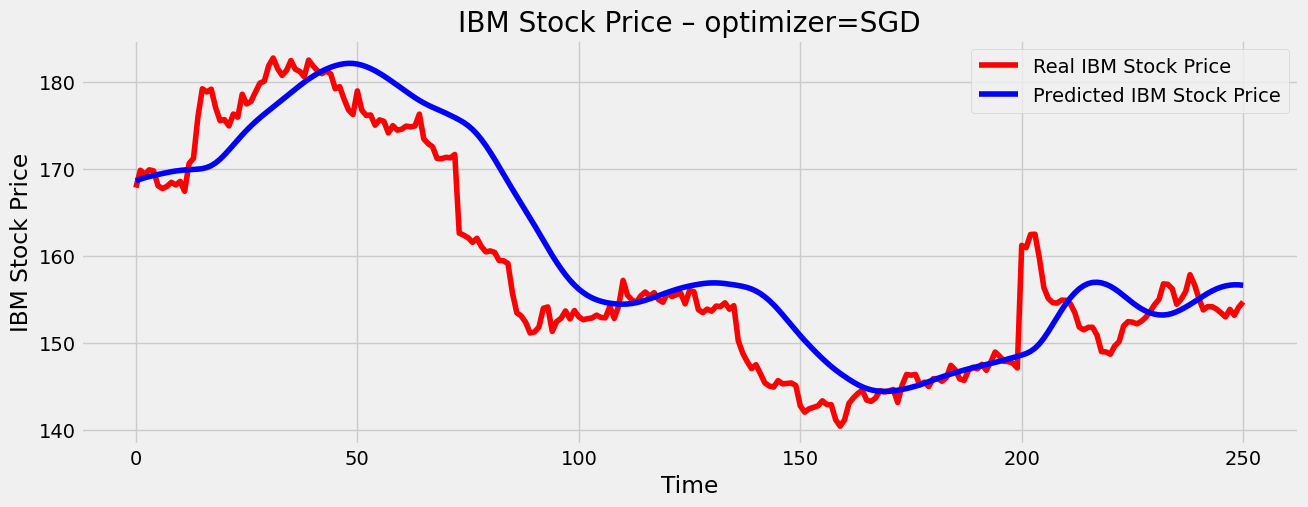

------------------------------
Błąd średniokwadratowy modelu 5.37.
------------------------------
Średni błąd bezwzględny: 3.98.
Średni błąd bezwzględny procentowy: 2.52%
------------------------------


In [20]:
for opt in ['rmsprop', 'adam', SGD(learning_rate=0.01, momentum=0.9)]:
    label = opt if isinstance(opt, str) else 'SGD'
    print(f"\n{'='*50}\nOptimizer: {label}\n{'='*50}")
    m = build_and_train_lstm(optimizer=opt, epochs=50)
    predict_and_evaluate(m, label=f'optimizer={label}')


Loss: MSE
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0202
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0098
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0080
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0069
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0062
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0055
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0054
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0043
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0043
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 

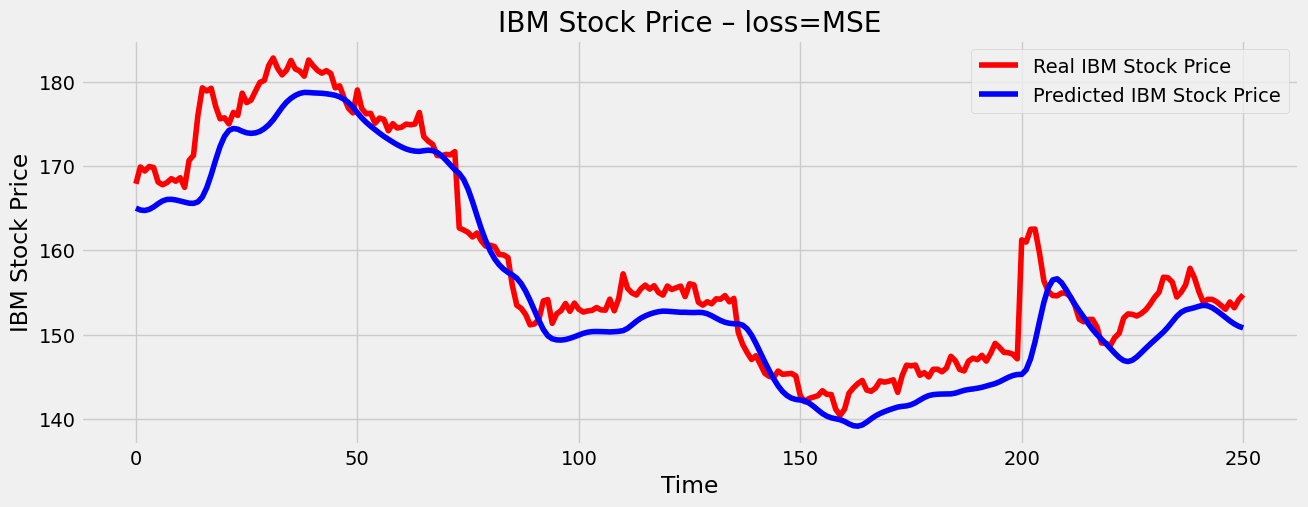

------------------------------
Błąd średniokwadratowy modelu 3.93.
------------------------------
Średni błąd bezwzględny: 3.10.
Średni błąd bezwzględny procentowy: 1.94%
------------------------------

Loss: MAE
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1134
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0776
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0680
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0638
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0578
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0553
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0538
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0515
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0506
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0473
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0471
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss:

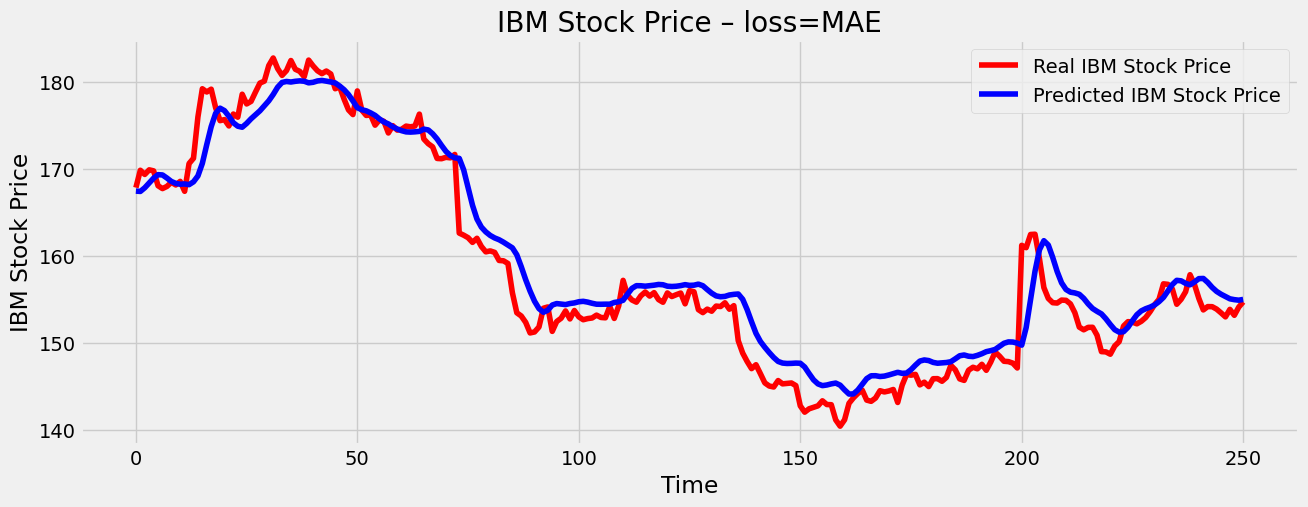

------------------------------
Błąd średniokwadratowy modelu 2.80.
------------------------------
Średni błąd bezwzględny: 2.16.
Średni błąd bezwzględny procentowy: 1.38%
------------------------------

Loss: Huber
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0108
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0050
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0041
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0035
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0027
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0019
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - los

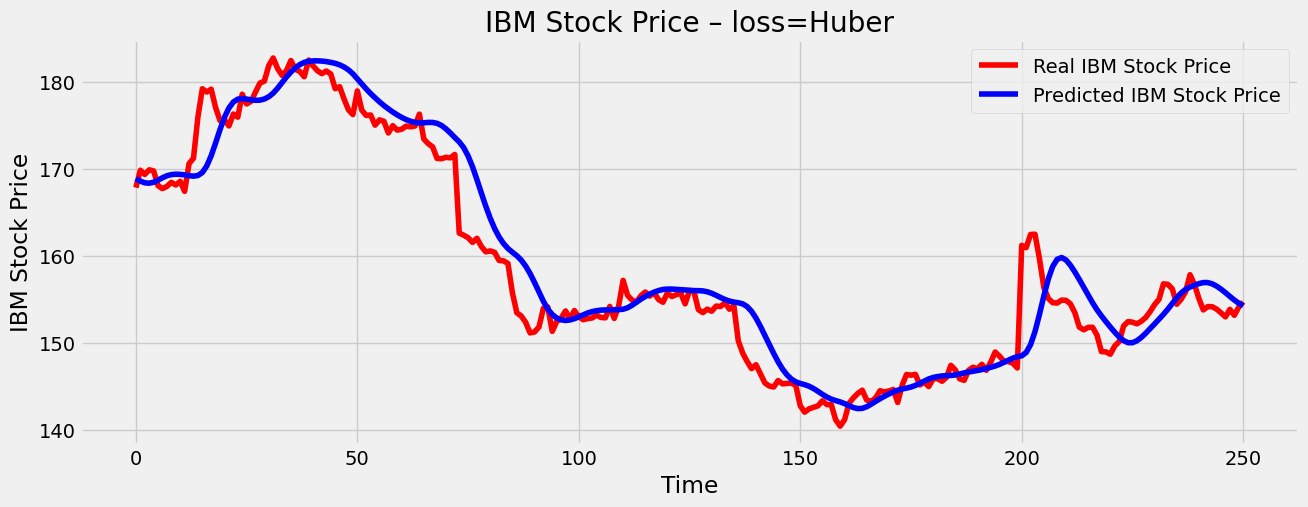

------------------------------
Błąd średniokwadratowy modelu 3.32.
------------------------------
Średni błąd bezwzględny: 2.30.
Średni błąd bezwzględny procentowy: 1.45%
------------------------------

Loss: LogCosh
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0099
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0053
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0040
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0032
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0028
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0027
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0021
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0019
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0018
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

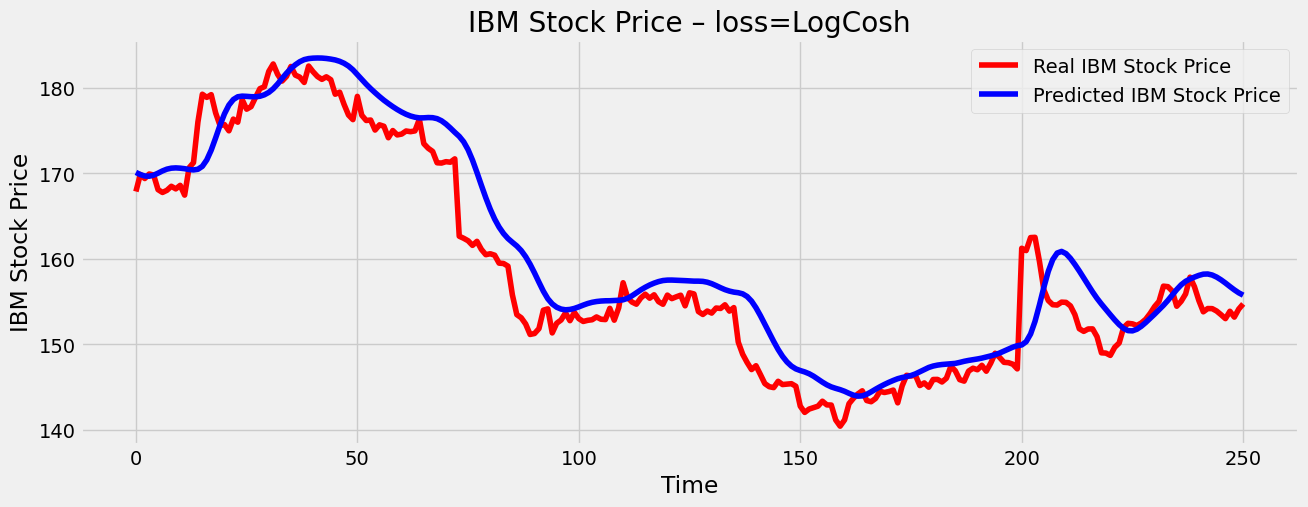

------------------------------
Błąd średniokwadratowy modelu 3.89.
------------------------------
Średni błąd bezwzględny: 3.01.
Średni błąd bezwzględny procentowy: 1.90%
------------------------------


In [26]:
import tensorflow as tf

losses_to_test = [
    ('MSE',     'mean_squared_error'),
    ('MAE',     'mean_absolute_error'),
    ('Huber',   tf.keras.losses.Huber()),
    ('LogCosh', tf.keras.losses.LogCosh()),
]

for label, loss_fn in losses_to_test:
    print(f"\n{'='*50}\nLoss: {label}\n{'='*50}")
    m = build_and_train_lstm(loss=loss_fn, epochs=50)
    predict_and_evaluate(m, label=f'loss={label}')

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0208
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0090
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0084
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0069
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0062
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0055
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0049
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0043
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0037
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0035
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0031
Epoc

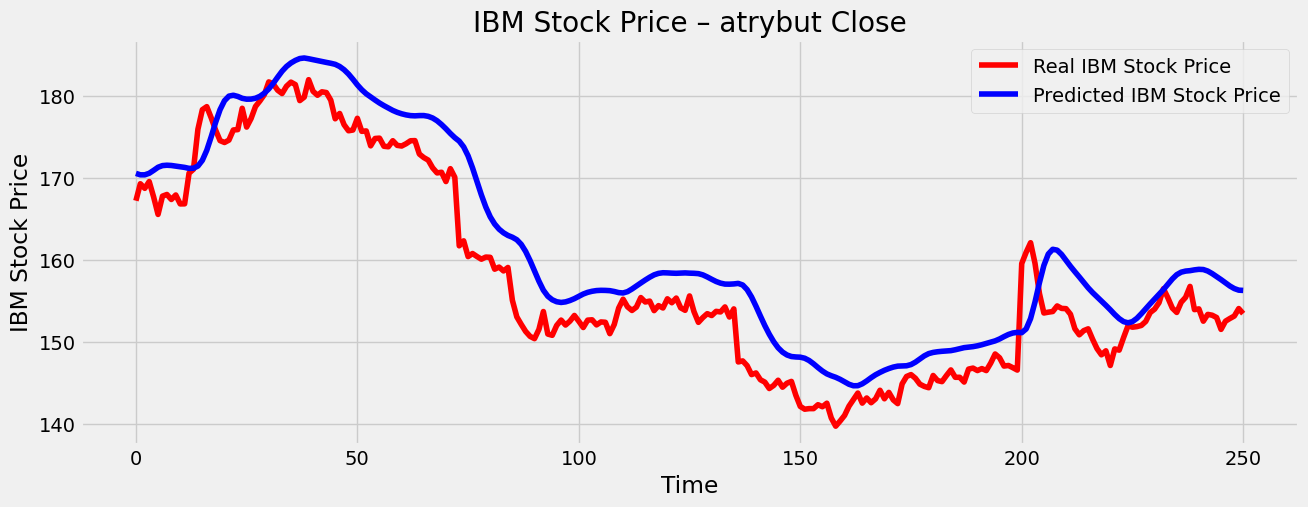

------------------------------
Błąd średniokwadratowy modelu 4.83.
------------------------------
Średni błąd bezwzględny: 4.27.
Średni błąd bezwzględny procentowy: 2.73%
------------------------------


In [27]:
training_set_close = dataset[:'2016'].iloc[:, 3:4].values
test_set_close     = dataset['2017':].iloc[:, 3:4].values

sc_close = MinMaxScaler(feature_range=(0, 1))
training_scaled_close = sc_close.fit_transform(training_set_close)

X_tr_c, y_tr_c = [], []
for i in range(60, len(training_scaled_close)):
    X_tr_c.append(training_scaled_close[i-60:i, 0])
    y_tr_c.append(training_scaled_close[i, 0])
X_tr_c = np.reshape(np.array(X_tr_c), (-1, 60, 1))
y_tr_c = np.array(y_tr_c)

model_close = build_and_train_lstm(epochs=50)

ds_total_close = pd.concat(
    (dataset["Close"][:'2016'], dataset["Close"]['2017':]), axis=0
)
inp_close = ds_total_close[len(ds_total_close) - len(test_set_close) - 60:].values.reshape(-1, 1)
inp_close = sc_close.transform(inp_close)

X_tc = []
for i in range(60, 60 + len(test_set_close)):
    X_tc.append(inp_close[i-60:i, 0])
X_tc = np.reshape(np.array(X_tc), (-1, 60, 1))

pred_close = sc_close.inverse_transform(model_close.predict(X_tc))
plot_predictions(test_set_close, pred_close, title='IBM Stock Price – atrybut Close')
return_rmse(test_set_close, pred_close)
return_mae(test_set_close, pred_close)

LSTM z Early Stopping (monitor=val_loss, patience=5, 100 epok)
Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0233 - val_loss: 0.0176
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0105 - val_loss: 0.0018
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0089 - val_loss: 0.0032
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0069 - val_loss: 0.0069
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0070 - val_loss: 0.0178
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0062 - val_loss: 0.0026
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0057 - val_loss: 0.0023
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


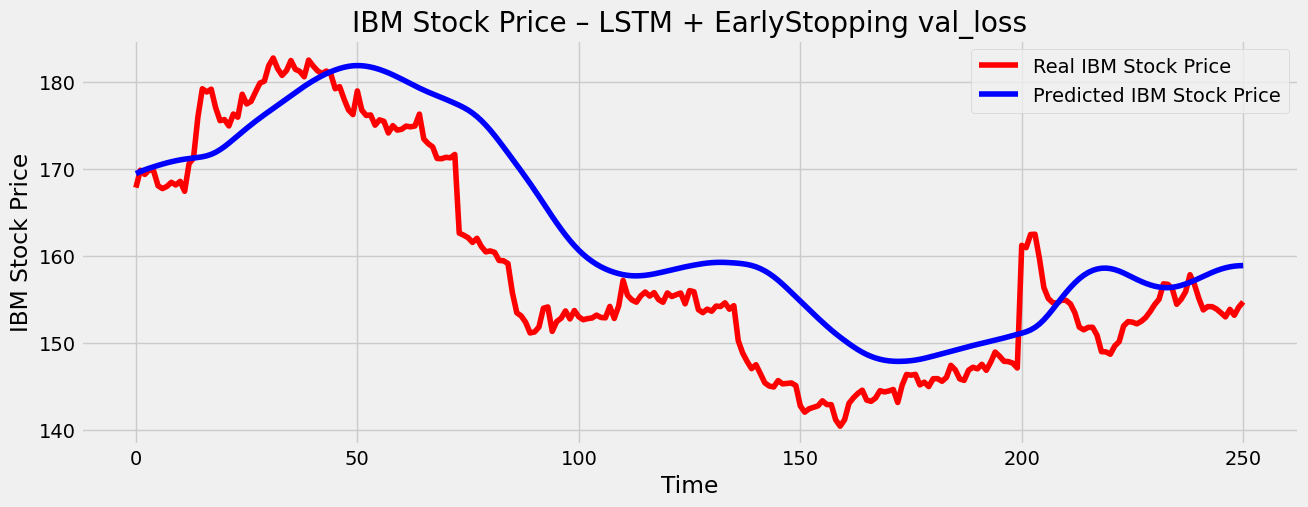

------------------------------
Błąd średniokwadratowy modelu 7.00.
------------------------------
Średni błąd bezwzględny: 5.68.
Średni błąd bezwzględny procentowy: 3.65%
------------------------------


array([[169.48518],
       [169.71687],
       [169.92094],
       [170.10373],
       [170.27199],
       [170.43124],
       [170.58202],
       [170.72226],
       [170.84978],
       [170.9637 ],
       [171.06352],
       [171.14981],
       [171.22153],
       [171.28409],
       [171.34517],
       [171.42142],
       [171.53496],
       [171.70343],
       [171.938  ],
       [172.23837],
       [172.59413],
       [172.99088],
       [173.41156],
       [173.84236],
       [174.27124],
       [174.69353],
       [175.10503],
       [175.5028 ],
       [175.88672],
       [176.25902],
       [176.62256],
       [176.9827 ],
       [177.34555],
       [177.71301],
       [178.08264],
       [178.45116],
       [178.81679],
       [179.17589],
       [179.52391],
       [179.85524],
       [180.16856],
       [180.4626 ],
       [180.73564],
       [180.98547],
       [181.21104],
       [181.41139],
       [181.58311],
       [181.72363],
       [181.82915],
       [181.89478],


In [28]:
print("LSTM z Early Stopping (monitor=val_loss, patience=5, 100 epok)")
m_es = build_and_train_lstm(
    epochs=100,
    early_stopping=True,
    patience=5,
    validation_split=0.1
)
predict_and_evaluate(m_es, label='LSTM + EarlyStopping val_loss')

Konfiguracja celująca w RMSE < 2.0
Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0218 - val_loss: 0.0016
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0034 - val_loss: 0.0014
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0027 - val_loss: 9.6481e-04
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0024 - val_loss: 9.1170e-04
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0025 - val_loss: 9.6051e-04
Epoch

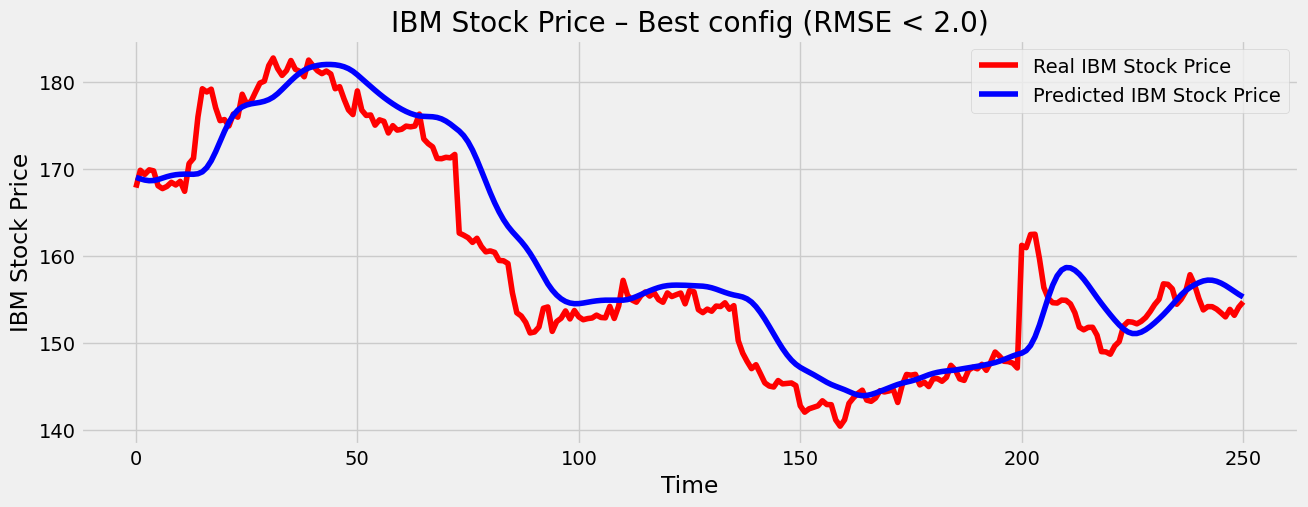

------------------------------
Błąd średniokwadratowy modelu 3.97.
------------------------------
Średni błąd bezwzględny: 2.88.
Średni błąd bezwzględny procentowy: 1.82%
------------------------------


array([[169.05235],
       [168.88333],
       [168.7416 ],
       [168.66876],
       [168.68927],
       [168.80316],
       [168.9677 ],
       [169.13281],
       [169.2656 ],
       [169.35756],
       [169.4076 ],
       [169.42712],
       [169.4123 ],
       [169.40962],
       [169.46869],
       [169.68837],
       [170.17406],
       [170.95534],
       [171.99565],
       [173.17786],
       [174.35005],
       [175.38992],
       [176.21089],
       [176.79689],
       [177.16292],
       [177.38402],
       [177.51547],
       [177.60066],
       [177.6841 ],
       [177.80875],
       [177.99901],
       [178.28436],
       [178.68352],
       [179.16887],
       [179.6835 ],
       [180.18147],
       [180.64725],
       [181.05826],
       [181.39467],
       [181.6373 ],
       [181.81032],
       [181.93266],
       [182.01097],
       [182.04514],
       [182.04253],
       [182.00827],
       [181.9232 ],
       [181.78079],
       [181.56587],
       [181.2597 ],


In [29]:
print("Konfiguracja celująca w RMSE < 2.0")
m_best = build_and_train_lstm(
    units=100,
    optimizer='adam',
    loss='mean_squared_error',
    epochs=100,
    early_stopping=True,
    patience=5,
    validation_split=0.1
)
predict_and_evaluate(m_best, label='Best config (RMSE < 2.0)')

Model wykorzystujący funkcję straty Huber (z domyślnymi 50 jednostkami LSTM i optymalizatorem RMSprop) osiągnął najniższy błąd średniokwadratowy (RMSE = 2.05) oraz najniższy średni błąd bezwzględny (MAE = 1.34) spośród wszystkich testowanych konfiguracji. Jest to znacząca poprawa w porównaniu do standardowego Mean Squared Error.

## Porównanie z aktualnymi cenami


In [34]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

DATA_SOURCE = None

try:
    import yfinance as yf
    raw = yf.download('IBM', start='2018-01-01', end=None, auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError("yfinance zwrócił pusty DataFrame")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    df_new = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df_new.index.name = 'Date'
    DATA_SOURCE = 'yfinance'
    print(f"yfinance: {len(df_new)} sesji ({df_new.index[0].date()} – {df_new.index[-1].date()})")
except Exception as e:
    print(f"yfinance niedostępne ({e})\nŁaduję IBM_2025_2026.csv ...")
    df_new = pd.read_csv('IBM_2025_2026.csv', index_col='Date', parse_dates=['Date'])
    df_new = df_new[['Open', 'High', 'Low', 'Close', 'Volume']]
    DATA_SOURCE = 'csv'
    print(f"CSV: {len(df_new)} sesji ({df_new.index[0].date()} – {df_new.index[-1].date()})")

full_high = pd.concat([dataset['High'], df_new['High']])
full_high = full_high[~full_high.index.duplicated(keep='last')].sort_index()

fig = make_subplots(rows=2, cols=1, shared_xaxes=False,
                    subplot_titles=('IBM – cena High (2006–2026)', 'IBM – zoom 2025–2026 (Candlestick)'))

fig.add_trace(go.Scatter(x=full_high.index, y=full_high.values,
    name='IBM High', line=dict(color='steelblue', width=0.8)), row=1, col=1)

for vline_x, vline_color, vline_label in [
    ('2017-01-01', 'orange', 'Koniec treningu'),
    ('2025-01-01', 'red',    'Dane 2025–2026'),
]:
    fig.add_shape(type='line', xref='x', yref='paper',
                  x0=vline_x, x1=vline_x, y0=0, y1=1,
                  line=dict(color=vline_color, dash='dash', width=1.5), row=1, col=1)
    fig.add_annotation(x=vline_x, y=1, xref='x', yref='paper',
                       text=vline_label, showarrow=False,
                       font=dict(color=vline_color), xanchor='left', row=1, col=1)

fig.add_trace(go.Candlestick(
    x=df_new.index,
    open=df_new['Open'], high=df_new['High'],
    low=df_new['Low'],   close=df_new['Close'],
    name='OHLC 2025–2026'), row=2, col=1)

fig.update_layout(height=750, xaxis2_rangeslider_visible=False)
fig.show()

print("\n── Zakres 'High' w zbiorze TRENINGOWYM (2006–2016) ──")
print(f"   Min = {training_set.min():.2f} USD")
print(f"   Max = {training_set.max():.2f} USD")
print("\n── Zakres 'High' w danych NOWYCH (2025–2026) ──")
print(f"   Min = {df_new['High'].min():.2f} USD")
print(f"   Max = {df_new['High'].max():.2f} USD")
print("\nDISTRIBUTION SHIFT: ceny 2025–2026 przekraczają maksimum treningowe!")

LOOKBACK = 60

full_series = pd.concat([dataset['High'], df_new['High']])
full_series = full_series[~full_series.index.duplicated(keep='last')].sort_index()

new_test_values = df_new['High'].values.reshape(-1, 1)

context_start = full_series.index.get_loc(df_new.index[0]) - LOOKBACK
context_values = full_series.iloc[context_start:].values.reshape(-1, 1)
context_scaled = sc.transform(context_values)

X_new = []
n_new = len(new_test_values)
for i in range(LOOKBACK, LOOKBACK + n_new):
    X_new.append(context_scaled[i - LOOKBACK:i, 0])
X_new = np.reshape(np.array(X_new), (-1, LOOKBACK, 1))

print(f"X_new shape: {X_new.shape}")
print(f"Scaled min: {X_new.min():.3f}, max: {X_new.max():.3f}")

pred_lstm_scaled = regressor.predict(X_new)
pred_lstm = sc.inverse_transform(pred_lstm_scaled)

pred_gru_scaled = regressorGRU.predict(X_new)
pred_gru = sc.inverse_transform(pred_gru_scaled)

dates_new = df_new.index[:n_new]

fig2 = make_subplots(rows=2, cols=1, shared_xaxes=True,
                     subplot_titles=('LSTM vs Rzeczywistość', 'GRU vs Rzeczywistość'))

fig2.add_trace(go.Scatter(x=dates_new, y=new_test_values.flatten(),
    name='Rzeczywista', line=dict(color='red', width=2)), row=1, col=1)
fig2.add_trace(go.Scatter(x=dates_new, y=pred_lstm.flatten(),
    name='LSTM', line=dict(color='blue', width=1.5, dash='dash')), row=1, col=1)

fig2.add_trace(go.Scatter(x=dates_new, y=new_test_values.flatten(),
    name='Rzeczywista', line=dict(color='red', width=2), showlegend=False), row=2, col=1)
fig2.add_trace(go.Scatter(x=dates_new, y=pred_gru.flatten(),
    name='GRU', line=dict(color='green', width=1.5, dash='dot')), row=2, col=1)

fig2.update_layout(height=700, title='IBM 2025–2026 – Predykcja vs Rzeczywistość')
fig2.show()

fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=dates_new, y=new_test_values.flatten(),
    name='Rzeczywista IBM High', line=dict(color='red', width=2)))
fig3.add_trace(go.Scatter(x=dates_new, y=pred_lstm.flatten(),
    name='LSTM', line=dict(color='blue', width=1.5, dash='dash')))
fig3.add_trace(go.Scatter(x=dates_new, y=pred_gru.flatten(),
    name='GRU', line=dict(color='green', width=1.5, dash='dot')))
fig3.update_layout(title='IBM 2025–2026 – LSTM vs GRU vs Rzeczywistość', height=500)
fig3.show()

print("═" * 45)
print("  METRYKI – LSTM na danych 2025–2026")
print("═" * 45)
return_rmse(new_test_values, pred_lstm)
return_mae(new_test_values, pred_lstm)

print("═" * 45)
print("  METRYKI – GRU na danych 2025–2026")
print("═" * 45)
return_rmse(new_test_values, pred_gru)
return_mae(new_test_values, pred_gru)

print(f"\n  {'Model':<12} {'Zbiór':<25} {'RMSE':>8} {'MAE':>8}")
print(f"  {'-'*55}")
for label, pred, actual in [
    ('LSTM', predicted_stock_price, test_set),
    ('LSTM', pred_lstm, new_test_values),
    ('GRU',  GRU_predicted_stock_price, test_set),
    ('GRU',  pred_gru, new_test_values),
]:
    zb = '2017 (in-distribution)' if actual is test_set else '2025-2026 (out-of-dist.)'
    rmse = math.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    print(f"  {label:<12} {zb:<25} {rmse:>8.2f} {mae:>8.2f}")

yfinance: 2099 sesji (2018-01-02 – 2026-05-08)



── Zakres 'High' w zbiorze TRENINGOWYM (2006–2016) ──
   Min = 73.94 USD
   Max = 215.90 USD

── Zakres 'High' w danych NOWYCH (2025–2026) ──
   Min = 72.00 USD
   Max = 320.70 USD

DISTRIBUTION SHIFT: ceny 2025–2026 przekraczają maksimum treningowe!
X_new shape: (2099, 60, 1)
Scaled min: -0.014, max: 1.738
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


═════════════════════════════════════════════
  METRYKI – LSTM na danych 2025–2026
═════════════════════════════════════════════
------------------------------
Błąd średniokwadratowy modelu 6.31.
------------------------------
Średni błąd bezwzględny: 4.28.
Średni błąd bezwzględny procentowy: 3.03%
------------------------------
═════════════════════════════════════════════
  METRYKI – GRU na danych 2025–2026
═════════════════════════════════════════════
------------------------------
Błąd średniokwadratowy modelu 4.50.
------------------------------
Średni błąd bezwzględny: 2.75.
Średni błąd bezwzględny procentowy: 1.87%
------------------------------

  Model        Zbiór                         RMSE      MAE
  -------------------------------------------------------
  LSTM         2017 (in-distribution)        3.25     2.28
  LSTM         2025-2026 (out-of-dist.)      6.31     4.28
  GRU          2017 (in-distribution)        3.32     2.75
  GRU          2025-2026 (out-of-dist.)     